# Coffee Quality Prediction
**Goal:** predict `total_cup_points` (regression) from coffee details plus **6 cup scores** (aroma, flavor, aftertaste, acidity, body, balance).

**Steps:** load data → clean → split → build pipeline → train 13 models with grid search → compare accuracy → pick the best model.

> **Accuracy** in this notebook = test R² shown as a percentage (regression has no classification accuracy). Higher is better. MAE = average error in cup points (lower is better).

## 1. Setup

In [2]:
import json, time, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, learning_curve
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor, HistGradientBoostingRegressor)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
TARGET = "total_cup_points"

DATA_CANDIDATES = [   # the first path that exists is used
    r"C:\Users\nagal\OneDrive\Desktop\Coffee_quality\data\raw\merged_data_cleaned.csv",
    "data/raw/merged_data_cleaned.csv", "data/raw/merged_data.csv",
    "../data/raw/merged_data_cleaned.csv", "../data/raw/merged_data.csv",
    "merged_data_cleaned.csv", "merged_data.csv",
]
MODELS_DIR, OUT_DIR = Path("models"), Path("outputs")
MODELS_DIR.mkdir(exist_ok=True); OUT_DIR.mkdir(exist_ok=True)
CV = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
print("Setup done.")

Setup done.


## 2. Load data

In [3]:
data_path = next((Path(p) for p in DATA_CANDIDATES if Path(p).exists()), None)
if data_path is None:
    raise FileNotFoundError("Put merged_data_cleaned.csv in data/raw/ or edit DATA_CANDIDATES above.")

data = pd.read_csv(data_path)
data.columns = (data.columns.str.strip().str.lower()
                .str.replace(".", "_", regex=False).str.replace(" ", "_", regex=False))
data = data.loc[:, ~data.columns.str.startswith("unnamed")]   # drop the saved index column
print("Loaded:", data_path, "->", data.shape)
data.head()

Loaded: C:\Users\nagal\OneDrive\Desktop\Coffee_quality\data\raw\merged_data_cleaned.csv -> (1339, 43)


,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,region,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


## 3. Data audit

In [4]:
audit = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_%": (data.isna().mean() * 100).round(1),
    "unique": data.nunique(),
})
print("Duplicate rows:", data.duplicated().sum())
print("Rows with target == 0:", (data[TARGET] == 0).sum())
audit.sort_values("missing_%", ascending=False).head(15)

Duplicate rows: 0
Rows with target == 0: 1


,dtype,missing,missing_%,unique
lot_number,str,1063,79.4,227
farm_name,str,359,26.8,571
mill,str,318,23.7,459
color,str,270,20.2,3
producer,str,232,17.3,692
altitude_high_meters,float64,230,17.2,198
altitude_low_meters,float64,230,17.2,198
altitude_mean_meters,float64,230,17.2,211
altitude,str,226,16.9,396
variety,str,226,16.9,29


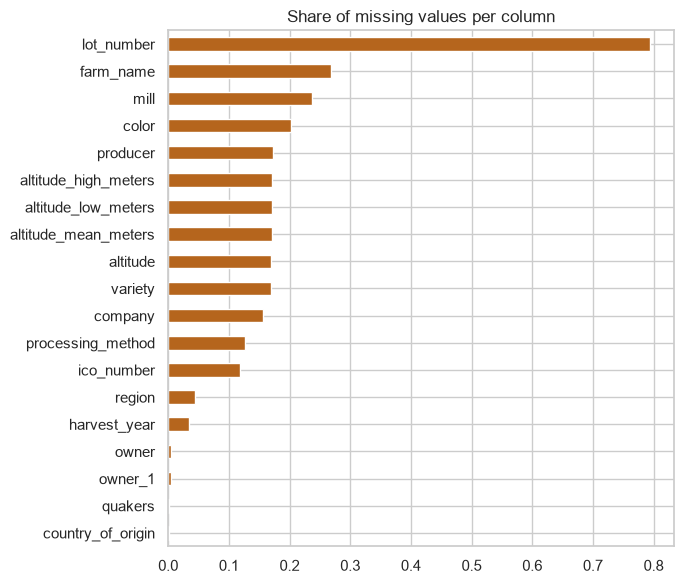

ID-like columns (owner, farm, lot, mill, company, producer, dates ...) are not used as features.


In [5]:
miss = data.isna().mean().sort_values(ascending=False)
miss[miss > 0].plot.barh(figsize=(7, 6), color="#b5651d")
plt.title("Share of missing values per column"); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
print("ID-like columns (owner, farm, lot, mill, company, producer, dates ...) are not used as features.")

## 4. Cleaning
Simple row/value fixes that do not learn from the data (safe before the split).
Imputation, scaling and encoding are done later inside the pipeline, fitted on training rows only.

In [6]:
df = data.copy()
report = {"start_rows": len(df)}

df = df.drop_duplicates();                       report["after_drop_duplicates"] = len(df)
df = df[df[TARGET] > 0].reset_index(drop=True);  report["after_drop_zero_target"] = len(df)

for c in ["altitude_low_meters", "altitude_high_meters", "altitude_mean_meters"]:
    report[f"{c}_set_nan(>5000m)"] = int((df[c] > 5000).sum())
    df.loc[df[c] > 5000, c] = np.nan             # impossible altitude (typo)
report["moisture_set_nan(>0.5)"] = int((df["moisture"] > 0.5).sum())
df.loc[df["moisture"] > 0.5, "moisture"] = np.nan
df["number_of_bags"] = df["number_of_bags"].clip(upper=df["number_of_bags"].quantile(0.99))   # cap outliers

CATEGORICAL = [c for c in ["species", "country_of_origin", "variety", "processing_method", "color"] if c in df.columns]
for c in CATEGORICAL:
    df[c] = df[c].astype("object").where(df[c].notna(), "Unknown").astype(str).str.strip()

print(pd.Series(report).to_string())
print("\nFinal shape:", df.shape)

start_rows                              1339
after_drop_duplicates                   1339
after_drop_zero_target                  1338
altitude_low_meters_set_nan(>5000m)        4
altitude_high_meters_set_nan(>5000m)       5
altitude_mean_meters_set_nan(>5000m)       4
moisture_set_nan(>0.5)                     0

Final shape: (1338, 43)


## 5. Target analysis

count    1338.00
mean       82.15
std         2.69
min        59.83
25%        81.10
50%        82.50
75%        83.67
max        90.58


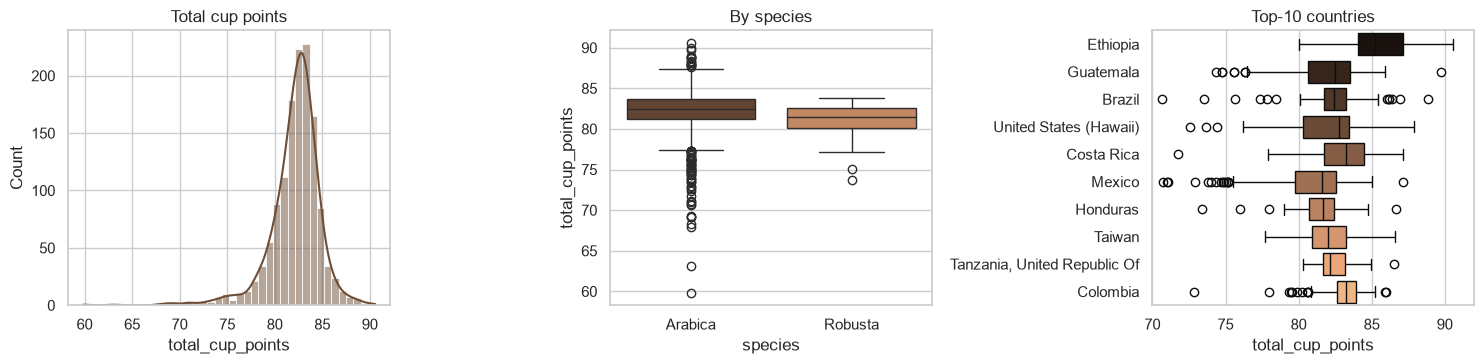

In [7]:
print(df[TARGET].describe().round(2).to_string())
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
sns.histplot(df[TARGET], bins=40, kde=True, ax=ax[0], color="#6f4e37"); ax[0].set_title("Total cup points")
sns.boxplot(data=df, x="species", y=TARGET, ax=ax[1], palette="copper"); ax[1].set_title("By species")
top = df["country_of_origin"].value_counts().head(10).index
sns.boxplot(data=df[df["country_of_origin"].isin(top)], y="country_of_origin", x=TARGET, ax=ax[2], palette="copper")
ax[2].set_title("Top-10 countries"); ax[2].set_xlim(70, 92); ax[2].set_ylabel("")
plt.tight_layout(); plt.show()

## 6. Features: metadata + 6 cup scores
| Group | Columns |
|---|---|
| Metadata (numeric) | moisture, defects, quakers, altitude (low / high / mean), number of bags |
| Metadata (categorical) | species, country, variety, processing method, colour |
| 6 cup scores | aroma, flavor, aftertaste, acidity, body, balance |

In [8]:
META_NUM = [c for c in ["moisture", "category_one_defects", "quakers", "category_two_defects",
                        "altitude_low_meters", "altitude_high_meters", "altitude_mean_meters", "number_of_bags"]
            if c in df.columns]
SENS6 = ["aroma", "flavor", "aftertaste", "acidity", "body", "balance"]

NUM_COLS = META_NUM + SENS6
FEATS = NUM_COLS + CATEGORICAL
print(f"{len(NUM_COLS)} numeric + {len(CATEGORICAL)} categorical = {len(FEATS)} features")

14 numeric + 5 categorical = 19 features


## 7. Train / test split
One **stratified** split (on target quintiles) is shared by every model, so accuracies are directly comparable.

In [9]:
bins = pd.qcut(df[TARGET], 5, labels=False, duplicates="drop")
idx_train, idx_test = train_test_split(df.index, test_size=TEST_SIZE, random_state=SEED, stratify=bins)
Xtr, Xte = df.loc[idx_train, FEATS], df.loc[idx_test, FEATS]
y_train, y_test = df.loc[idx_train, TARGET], df.loc[idx_test, TARGET]
print("train:", len(idx_train), "| test:", len(idx_test))
print("target mean  train/test:", round(y_train.mean(), 2), "/", round(y_test.mean(), 2))

train: 1070 | test: 268
target mean  train/test: 82.18 / 82.05


## 8. Preprocessing pipeline
- **Numeric:** median imputation → standard scaling
- **Categorical:** fill missing with "Unknown" → one-hot encoding (rare categories grouped, unseen ones handled)

It is fitted inside cross-validation on training folds only, so no information leaks from validation rows.

In [10]:
def build_preprocessor():
    num = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    cat = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5, sparse_output=False))])
    return ColumnTransformer([("num", num, NUM_COLS), ("cat", cat, CATEGORICAL)])

_Xt = build_preprocessor().fit_transform(Xtr)
print("Processed train matrix:", _Xt.shape, "| NaNs left:", int(np.isnan(_Xt).sum()))

Processed train matrix: (1070, 69) | NaNs left: 0


## 9. Models and hyper-parameter grids
13 models plus a **dummy** model that always predicts the mean (the score to beat).
The target is standardised inside each pipeline (`TransformedTargetRegressor`) so models like SGD and SVR behave well.

In [11]:
def make_models():
    return {
        "dummy_mean":        (DummyRegressor(strategy="mean"), {}),
        "linear_regression": (LinearRegression(), {}),
        "lasso":   (Lasso(max_iter=10000), {"model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}),
        "ridge":   (Ridge(), {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}),
        "sgd":     (SGDRegressor(random_state=SEED, max_iter=5000),
                    {"model__alpha": [0.0001, 0.001, 0.01], "model__penalty": ["l2", "l1", "elasticnet"]}),
        "elastic_net": (ElasticNet(random_state=SEED, max_iter=10000),
                    {"model__alpha": [0.001, 0.01, 0.1, 1.0], "model__l1_ratio": [0.2, 0.5, 0.8]}),
        "svr":     (SVR(), {"model__C": [0.1, 1, 10, 100], "model__epsilon": [0.01, 0.1, 0.2], "model__gamma": ["scale", "auto"]}),
        "kneighbors": (KNeighborsRegressor(), {"model__n_neighbors": [3, 5, 7, 10], "model__weights": ["uniform", "distance"]}),
        "decision_tree": (DecisionTreeRegressor(random_state=SEED),
                    {"model__max_depth": [3, 5, 10, None], "model__min_samples_leaf": [1, 2, 4]}),
        "random_forest": (RandomForestRegressor(random_state=SEED),
                    {"model__n_estimators": [100, 200], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2, 4]}),
        "extra_trees": (ExtraTreesRegressor(random_state=SEED),
                    {"model__n_estimators": [200, 400], "model__max_depth": [None, 15], "model__min_samples_leaf": [1, 2, 4]}),
        "adaboost": (AdaBoostRegressor(random_state=SEED),
                    {"model__n_estimators": [50, 100, 200], "model__learning_rate": [0.01, 0.1, 1.0]}),
        "gradient_boosting": (GradientBoostingRegressor(random_state=SEED),
                    {"model__n_estimators": [100, 200], "model__learning_rate": [0.01, 0.05, 0.1], "model__max_depth": [2, 3, 5]}),
        "hist_gradient_boosting": (HistGradientBoostingRegressor(random_state=SEED),
                    {"model__learning_rate": [0.03, 0.1], "model__max_depth": [3, None], "model__min_samples_leaf": [10, 20]}),
    }

def metrics(y_true, y_hat):
    return dict(mae=mean_absolute_error(y_true, y_hat),
                rmse=float(np.sqrt(mean_squared_error(y_true, y_hat))),
                r2=r2_score(y_true, y_hat))

def accuracy(y_true, y_hat):
    """Accuracy (%) = R² x 100"""
    return 100 * r2_score(y_true, y_hat)

print(len(make_models()), "models ready (including the dummy baseline)")

14 models ready (including the dummy baseline)


## 10. Train every model
Each model is tuned with 5-fold `GridSearchCV` on the **training set only**; the test set is used once per model for reporting.
The accuracy of each model is printed as soon as it finishes. This cell takes a few minutes.

In [ ]:
rows, FITTED = [], {}
print(f"{'Model':24s}{'CV acc %':>10}{'Train acc %':>13}{'Test acc %':>12}{'Test MAE':>10}")
print("-" * 69)

for name, (est, grid) in make_models().items():
    t0 = time.time()
    pipe = TransformedTargetRegressor(
        regressor=Pipeline([("preprocessor", build_preprocessor()), ("model", est)]),
        transformer=StandardScaler())
    search = GridSearchCV(pipe, {"regressor__" + k: v for k, v in grid.items()},
                          cv=CV, scoring="r2", n_jobs=-1)
    search.fit(Xtr, y_train)
    best = search.best_estimator_

    te = metrics(y_test, best.predict(Xte))
    rows.append(dict(model=name,
                     cv_r2=search.best_score_,
                     train_r2=r2_score(y_train, best.predict(Xtr)),
                     test_r2=te["r2"], test_mae=te["mae"], test_rmse=te["rmse"],
                     best_params={k.replace("regressor__model__", ""): v for k, v in search.best_params_.items()}))
    FITTED[name] = best
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(best, MODELS_DIR / f"{name}.pkl")
    print(f"{name:24s}{100*search.best_score_:>10.2f}{100*rows[-1]['train_r2']:>13.2f}"
          f"{100*te['r2']:>12.2f}{te['mae']:>10.3f}")

RESULTS = pd.DataFrame(rows)
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS.drop(columns="best_params").round(4).to_csv(OUT_DIR / "all_model_results.csv", index=False)

Model                     CV acc %  Train acc %  Test acc %  Test MAE
---------------------------------------------------------------------
dummy_mean                   -0.39         0.00       -0.16     1.960
linear_regression            76.51        79.28       77.05     0.802
lasso                        77.28        79.05       80.12     0.758
ridge                        77.35        79.12       80.13     0.758
sgd                          77.29        78.59       80.01     0.765
elastic_net                  77.53        78.72       80.04     0.750
svr                          75.27        84.87       80.74     0.645
kneighbors                   68.90       100.00       75.54     0.826
decision_tree                70.14        80.58       77.13     0.918
random_forest                78.12        88.70       83.38     0.731
extra_trees                  77.88       100.00       84.37     0.659
adaboost                     70.97        78.95       78.04     0.919
gradient_boosting   

OSError: Cannot save file into a non-existent directory: 'outputs'

## 11. Accuracy of every model (sorted by cross-validated accuracy)

In [ ]:
table = RESULTS.assign(**{"cv_accuracy_%": 100 * RESULTS.cv_r2,
                          "train_accuracy_%": 100 * RESULTS.train_r2,
                          "test_accuracy_%": 100 * RESULTS.test_r2})
table = table.sort_values("cv_accuracy_%", ascending=False).reset_index(drop=True)
table.index += 1
display(table[["model", "cv_accuracy_%", "train_accuracy_%", "test_accuracy_%", "test_mae", "test_rmse"]].round(2))

plot = table.sort_values("test_accuracy_%")
plt.figure(figsize=(8, 6))
bars = plt.barh(plot["model"], plot["test_accuracy_%"], color="#b5651d")
plt.bar_label(bars, fmt="%.1f", padding=3)
plt.xlabel("Test accuracy (R² %)"); plt.title("Test accuracy of every model")
plt.tight_layout(); plt.savefig(OUT_DIR / "model_accuracy.png", dpi=140); plt.show()

## 12. Best model
The best model is the one with the highest **cross-validated** accuracy (dummy excluded).
Choosing by test score would quietly tune the model to the test set.

In [ ]:
ranked = RESULTS[RESULTS.model != "dummy_mean"].sort_values("cv_r2", ascending=False)
best_row = ranked.iloc[0]
champ_name = best_row.model
champ = FITTED[champ_name]
pred = champ.predict(Xte); err = pred - y_test.values
dummy_mae = RESULTS.query("model == 'dummy_mean'")["test_mae"].iloc[0]

print(f"Best model      : {champ_name}")
print(f"Best parameters : {best_row.best_params}")
print(f"CV accuracy     : {100*best_row.cv_r2:.2f} %")
print(f"Test accuracy   : {accuracy(y_test, pred):.2f} %")
print(f"Test MAE        : {best_row.test_mae:.3f} points (always guessing the mean gives {dummy_mae:.3f})")

## 13. Best model: diagnostics

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(y_test, pred, alpha=.5, color="#6f4e37"); lo, hi = y_test.min(), y_test.max()
ax[0].plot([lo, hi], [lo, hi], "r--"); ax[0].set(xlabel="Actual", ylabel="Predicted", title=f"{champ_name}: predicted vs actual")
sns.histplot(err, bins=35, kde=True, ax=ax[1], color="#6f4e37"); ax[1].axvline(0, color="r", ls="--"); ax[1].set_title("Residuals (pred - actual)")
ax[2].scatter(pred, err, alpha=.5, color="#6f4e37"); ax[2].axhline(0, color="r", ls="--"); ax[2].set(xlabel="Predicted", ylabel="Residual", title="Residuals vs predicted")
plt.tight_layout(); plt.savefig(OUT_DIR / "best_model_diagnostics.png", dpi=140); plt.show()

print(f"{champ_name} test accuracy: {accuracy(y_test, pred):.2f} %")
print(f"Within +-1 point: {(abs(err) <= 1).mean():.1%} | within +-2: {(abs(err) <= 2).mean():.1%} | within +-3: {(abs(err) <= 3).mean():.1%}")

### Where does the best model make its biggest errors?

In [ ]:
te_rows = df.loc[idx_test].assign(pred=pred, abs_err=np.abs(err))
by_species = te_rows.groupby("species")["abs_err"].agg(["count", "mean"]).round(3)
top_c = te_rows["country_of_origin"].value_counts().head(8).index
by_country = (te_rows[te_rows.country_of_origin.isin(top_c)].groupby("country_of_origin")["abs_err"]
              .agg(["count", "mean"]).round(3).sort_values("mean"))
display(by_species); display(by_country)

worst = te_rows.nlargest(10, "abs_err")[["species", "country_of_origin", "variety", TARGET, "pred", "abs_err"]].round(2)
worst.to_csv(OUT_DIR / "largest_errors.csv", index=False)
display(worst)
print(f"{champ_name} test accuracy: {accuracy(y_test, pred):.2f} %")

### Which columns matter most? (permutation importance)

In [ ]:
pi = permutation_importance(champ, Xte, y_test, n_repeats=15, random_state=SEED, scoring="r2", n_jobs=-1)
imp = pd.DataFrame({"feature": FEATS, "importance": pi.importances_mean, "std": pi.importances_std}).sort_values("importance")
imp.tail(15).plot.barh(x="feature", y="importance", xerr=imp.tail(15)["std"], legend=False, figsize=(7, 5), color="#b5651d")
plt.title("Permutation importance (drop in R² when a column is shuffled)"); plt.tight_layout()
plt.savefig(OUT_DIR / "permutation_importance.png", dpi=140); plt.show()
imp.sort_values("importance", ascending=False).to_csv(OUT_DIR / "permutation_importance.csv", index=False)
print(f"{champ_name} test accuracy: {accuracy(y_test, pred):.2f} %")

### Would more data help? (learning curve)

In [ ]:
sizes, tr_sc, va_sc = learning_curve(clone(champ), Xtr, y_train, cv=CV, scoring="r2",
                                     train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1, random_state=SEED, shuffle=True)
plt.figure(figsize=(6.5, 4))
plt.plot(sizes, 100 * tr_sc.mean(1), "o-", label="train")
plt.plot(sizes, 100 * va_sc.mean(1), "o-", label="cross-validation")
plt.fill_between(sizes, 100 * (va_sc.mean(1) - va_sc.std(1)), 100 * (va_sc.mean(1) + va_sc.std(1)), alpha=.15)
plt.xlabel("Training rows"); plt.ylabel("Accuracy (R² %)"); plt.title("Learning curve"); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR / "learning_curve.png", dpi=140); plt.show()
print(f"{champ_name} at full size -> train accuracy: {100*tr_sc.mean(1)[-1]:.2f} % | CV accuracy: {100*va_sc.mean(1)[-1]:.2f} %")

### How certain is the test accuracy? (bootstrap 95% interval)

In [ ]:
rng = np.random.default_rng(SEED); yt = y_test.values; n = len(yt); r2s, maes = [], []
for _ in range(2000):
    i = rng.integers(0, n, n)
    r2s.append(r2_score(yt[i], pred[i])); maes.append(mean_absolute_error(yt[i], pred[i]))
ci = lambda a: (np.percentile(a, 2.5), np.percentile(a, 97.5))
print(f"{champ_name} test accuracy = {100*r2_score(yt, pred):.2f} %  (95% CI {100*ci(r2s)[0]:.2f} to {100*ci(r2s)[1]:.2f})")
print(f"{champ_name} test MAE      = {mean_absolute_error(yt, pred):.3f}  (95% CI {ci(maes)[0]:.3f} to {ci(maes)[1]:.3f})")
print(f"The test set has only {n} rows, so small accuracy differences between models are not meaningful.")

## 14. Save the best model and predict new coffees
The saved file is the **whole pipeline** (imputation → scaling → encoding → model), so raw columns go in and cup points come out.

In [ ]:
model_path = MODELS_DIR / "best_model.pkl"
joblib.dump(champ, model_path)
(MODELS_DIR / "best_model_info.json").write_text(json.dumps({
    "model": champ_name, "target": TARGET,
    "numeric_features": NUM_COLS, "categorical_features": CATEGORICAL,
    "cv_accuracy_%": round(100 * float(best_row.cv_r2), 2),
    "test_accuracy_%": round(float(accuracy(y_test, pred)), 2),
    "test_mae": round(float(best_row.test_mae), 3),
}, indent=2))

reloaded = joblib.load(model_path)
print("Reloaded model gives identical predictions:", np.array_equal(reloaded.predict(Xte), pred))
print(f"{champ_name} test accuracy: {accuracy(y_test, reloaded.predict(Xte)):.2f} %")

def predict_quality(rows: pd.DataFrame) -> np.ndarray:
    """rows: DataFrame with the feature columns (missing values are allowed, they are imputed)."""
    rows = rows.copy()
    for c in FEATS:
        if c not in rows.columns: rows[c] = np.nan
    return reloaded.predict(rows[FEATS])

sample = df.loc[idx_test].head(5)
print(pd.DataFrame({"actual": sample[TARGET].values, "predicted": predict_quality(sample).round(2)}))

## 15. Conclusion

In [ ]:
final = RESULTS.assign(test_accuracy=100 * RESULTS.test_r2, cv_accuracy=100 * RESULTS.cv_r2)
final = final.sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
final.index += 1

print("ACCURACY OF EVERY MODEL (metadata + 6 cup scores)")
print(f"{'Rank':<5}{'Model':24s}{'CV acc %':>10}{'Test acc %':>12}{'Test MAE':>10}")
for r, row in final.iterrows():
    tag = "  <-- BEST" if row.model == champ_name else ""
    print(f"{r:<5}{row.model:24s}{row.cv_accuracy:>10.2f}{row.test_accuracy:>12.2f}{row.test_mae:>10.3f}{tag}")

top_test = final[final.model != "dummy_mean"].sort_values("test_accuracy", ascending=False).iloc[0]
print("\n" + "=" * 70)
print(f"BEST MODEL: {champ_name}")
print(f"  Test accuracy (R²): {accuracy(y_test, pred):.2f} %   |   CV accuracy: {100*best_row.cv_r2:.2f} %")
print(f"  Average error     : {best_row.test_mae:.2f} cup points (dummy baseline: {dummy_mae:.2f})")
print("=" * 70)
if top_test.test_accuracy > accuracy(y_test, pred) + 0.05:
    print(f"Note: {top_test.model} scored slightly higher on the test set ({top_test.test_accuracy:.2f} %), but the best model is chosen "
          "by cross-validation, which is more reliable than a single 20% test split.")
print("\nSummary:")
top3 = final[final.model != "dummy_mean"].head(3)
print("1. Top 3 by cross-validation:", ", ".join(f"{m} ({a:.2f} %)" for m, a in zip(top3.model, top3.cv_accuracy)) + ". Small gaps between top models are within test-set noise.")
print("2. Every model beats the dummy baseline by a wide margin.")
print("3. The 6 cup scores are only known after tasting, so this model predicts the total score of a coffee that has already been cupped.")